### 24RB1075　小嶋将太郎

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
HEIGHT, WIDTH = 4, 12
START = (3, 0)
GOAL = (3, 11)
EPS = 0.1
ALPHA = 0.5
GAMMA = 1.0
NUM_EPISODES = 500

ACTIONS = [0, 1, 2, 3] #[上,下,左,右]

def step(state, action):
    y, x = state
    if action == 0:
        y = max(y - 1, 0) #上
    elif action == 1:
        y = min(y + 1, HEIGHT - 1) #下
    elif action == 2:
        x = max(x - 1, 0) #左
    elif action == 3:
        x = min(x + 1, WIDTH - 1) #右

    if y == 3 and 1<= x <= 10:
        return START, -100, False

    if (y, x) == GOAL:
        return GOAL, -1, True

    return (y, x), -1, False

def select_action(state, Q, eps=EPS):
    if np.random.rand() < eps:
        return np.random.choice(ACTIONS)
    else:
        q_values = Q[state[0], state[1]]
        return np.random.choice(np.flatnonzero(q_values == q_values.max()))
    


### SARSA

In [16]:
Q_sarsa = np.zeros((HEIGHT, WIDTH, 4))
rewards_sarsa = []

for episode in range(NUM_EPISODES):
    S = START
    A = select_action(S, Q_sarsa)
    done = False
    total_reward = 0

    while not done:
        S_next, R, done = step(S, A)
        total_reward += R

        A_next = select_action(S_next, Q_sarsa)

        target = R + GAMMA * Q_sarsa[S_next[0], S_next[1], A_next]
        Q_sarsa[S[0], S[1], A] += ALPHA * (target - Q_sarsa[S[0], S[1], A])

        S = S_next
        A = A_next

    rewards_sarsa.append(total_reward)

### Q学習

In [17]:
Q_qlearning = np.zeros((HEIGHT, WIDTH, 4))
rewards_qlearning = []

for episode in range(NUM_EPISODES):
    S = START
    done = False
    total_reward = 0

    while not done:
        A = select_action(S, Q_qlearning)

        S_next, R, done = step(S, A)
        total_reward += R

        max_q_next = np.max(Q_qlearning[S_next[0], S_next[1]])
        target = R + GAMMA * max_q_next
        Q_qlearning[S[0], S[1], A] += ALPHA * (target - Q_qlearning[S[0], S[1], A])

        S = S_next
        
    rewards_qlearning.append(total_reward)

In [22]:
def print_policy(Q, title):
    print(f"\n=== {title} の貪欲方針 ===")
    action_symbols = ["↑", "↓", "←", "→"]
    
    for y in range(HEIGHT):
        row_str = ""
        for x in range(WIDTH):
            if (y, x) == START:
                row_str += " S "
            elif (y, x) == GOAL:
                row_str += " G "
            elif y == 3 and 1 <= x <= 10:
                row_str += " C "
            else:
                best_a = np.argmax(Q[y, x])
                row_str += f" {action_symbols[best_a]} "
        print(row_str)

print_policy(Q_sarsa, "SARSA")
print_policy(Q_qlearning, "Q学習")


=== SARSA の貪欲方針 ===
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 →  →  →  ↑  ↑  ↑  →  →  ↑  ↑  ↑  ↓ 
 ↑  ↑  ↑  ↑  ←  ↑  ←  ↑  ↑  ↑  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 

=== Q学習 の貪欲方針 ===
 →  ←  ↑  →  →  →  ↑  →  ↓  →  ←  ↓ 
 →  ↓  →  →  ↓  →  ↓  ↓  →  →  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 


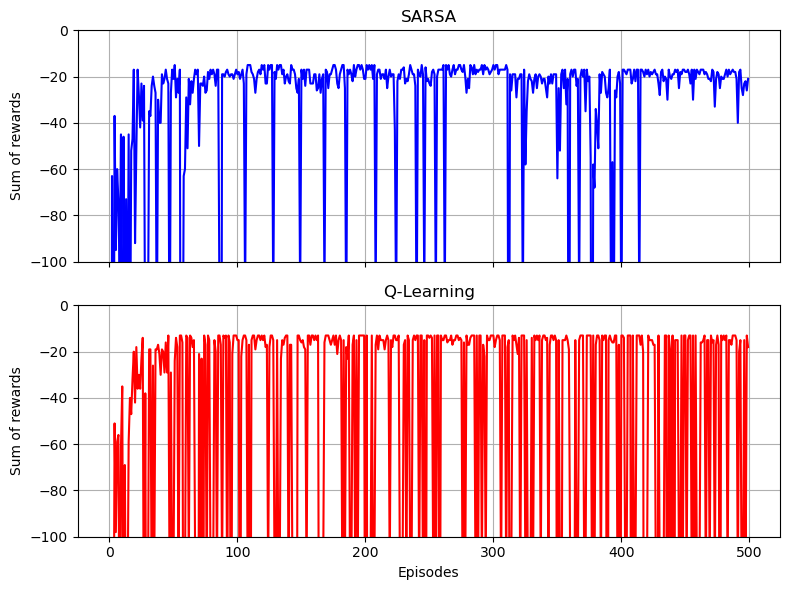

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# 上段: SARSA
axes[0].plot(rewards_sarsa, color="blue")
axes[0].set_title("SARSA")
axes[0].set_ylabel("Sum of rewards")
axes[0].set_ylim(-100, 0)
axes[0].grid(True)

# 下段: Q学習
axes[1].plot(rewards_qlearning, color="red")
axes[1].set_title("Q-Learning")
axes[1].set_xlabel("Episodes")
axes[1].set_ylabel("Sum of rewards")
axes[1].set_ylim(-100, 0)
axes[1].grid(True)

plt.tight_layout()
plt.show()

###

### 考察
Q学習は崖際を通る理論上の最短経路を学ぶため、たまに起きるランダムな探索行動で頻繁に崖に落ちてペナルティ（-100）を受けた。一方、SARSAは探索時の失敗リスクも考慮して安全な遠回りを学ぶため、学習中のミスが少なく、合計報酬が安定して高くなることが分かった。

### AIの使用
エピソード毎の合計報酬の推移を可視化する手順で使用した。